# ⏳ Time Series Analysis

## Business Objective

Understanding historical sales trends helps businesses forecast future demand, optimize inventory, and identify seasonal patterns.

### Business Questions

1. 📈 Are sales growing over time?
2. 📅 Which months generate the highest revenue?
3. 🎄 Is there any seasonality in sales?
4. 📉 Which quarter underperforms?
5. 💹 Does profit follow the same trend as sales?

This analysis will help management identify peak business periods and make informed strategic decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (12,6)

df = pd.read_csv('../data/Superstore.csv', encoding="latin1")

In [3]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [4]:
monthly_summary = (

    df

    .groupby(

        df["Order Date"].dt.to_period("M")

    )

    .agg(

        Total_Sales=("Sales","sum"),

        Total_Profit=("Profit","sum"),

        Orders=("Order ID","nunique")

    )

)

monthly_summary.index = monthly_summary.index.astype(str)

monthly_summary.head()

,Total_Sales,Total_Profit,Orders
Order Date,,,
2014-01,14236.895,2450.1907,32
2014-02,4519.892,862.3084,28
2014-03,55691.009,498.7299,71
2014-04,28295.345,3488.8352,66
2014-05,23648.287,2738.7096,69


In [5]:
monthly_summary.style.format({

"Total_Sales":"${:,.2f}",

"Total_Profit":"${:,.2f}"

}).background_gradient(cmap="Blues")

,Total_Sales,Total_Profit,Orders
Order Date,,,
2014-01,"$14,236.90","$2,450.19",32
2014-02,"$4,519.89",$862.31,28
2014-03,"$55,691.01",$498.73,71
2014-04,"$28,295.35","$3,488.84",66
2014-05,"$23,648.29","$2,738.71",69
2014-06,"$34,595.13","$4,976.52",66
2014-07,"$33,946.39",$-841.48,65
2014-08,"$27,909.47","$5,318.10",72
2014-09,"$81,777.35","$8,328.10",130


C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


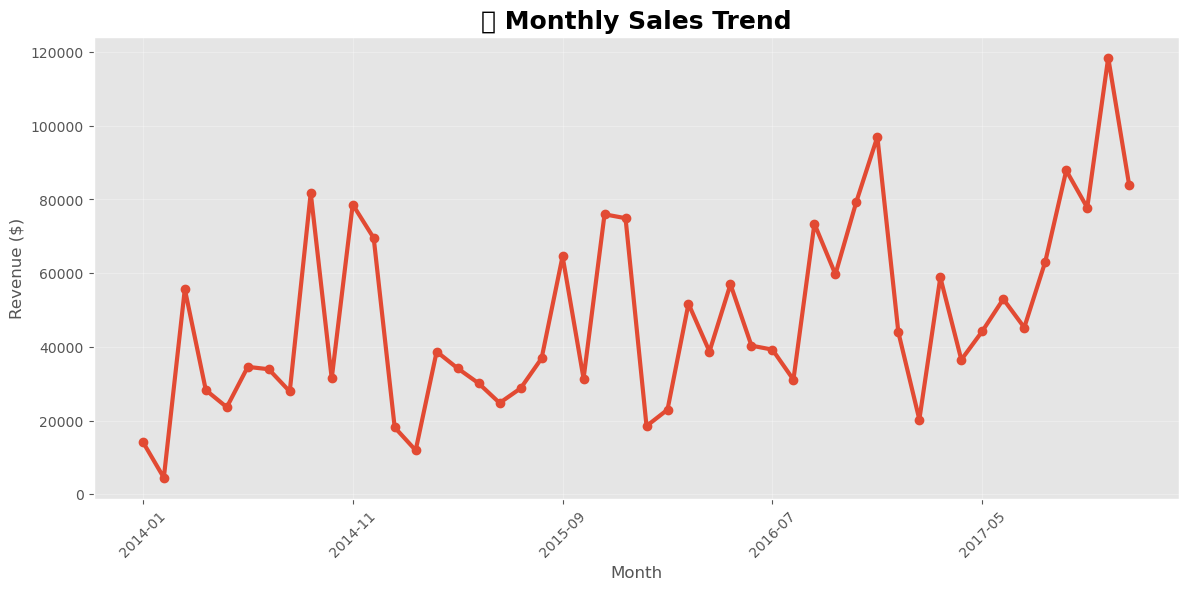

In [6]:
ax=(

monthly_summary

["Total_Sales"]

.plot(

figsize=(14,6),

marker="o",

linewidth=3

)

)

plt.title(

"📈 Monthly Sales Trend",

fontsize=18,

fontweight="bold"

)

plt.xlabel("Month")

plt.ylabel("Revenue ($)")

plt.xticks(rotation=45)

plt.grid(alpha=.3)

plt.show()

## 🧠 Business Insight

This visualization highlights the monthly sales trend over the analysis period.

Questions to consider:

- Is the business growing consistently?
- Are there sudden spikes or declines?
- Which months require further investigation?

Understanding these trends enables better forecasting and inventory planning.

In [7]:
monthly_sales = (

df

.groupby(

df["Order Date"].dt.month_name()

)

["Sales"]

.sum()

.reindex([

"January",

"February",

"March",

"April",

"May",

"June",

"July",

"August",

"September",

"October",

"November",

"December"

])

)

monthly_sales

Order Date
January       94924.8356
February      59751.2514
March        205005.4888
April        137762.1286
May          155028.8117
June         152718.6793
July         147238.0970
August       159044.0630
September    307649.9457
October      200322.9847
November     352461.0710
December     325293.5035
Name: Sales, dtype: float64

C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


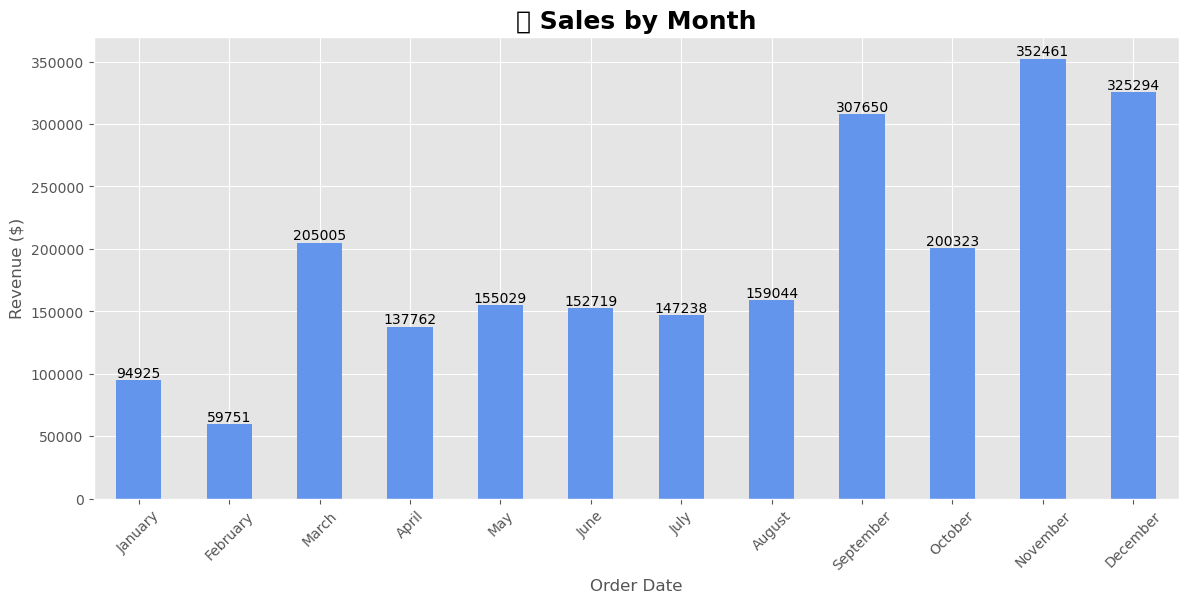

In [8]:
ax=(

monthly_sales

.plot(

kind="bar",

figsize=(14,6),

color="cornflowerblue"

)

)

plt.title(

"📅 Sales by Month",

fontsize=18,

fontweight="bold"

)

plt.ylabel("Revenue ($)")

plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f")

plt.show()

## 🧠 Business Insight

Monthly sales analysis helps identify high-demand periods.

Peak-performing months can be leveraged through:

- Marketing campaigns
- Promotional events
- Inventory optimization

Low-performing months may require strategic interventions to improve revenue.

In [9]:
quarter_summary=(

df

.groupby(

df["Order Date"].dt.quarter

)

.agg(

Sales=("Sales","sum"),

Profit=("Profit","sum")

)

)

quarter_summary

,Sales,Profit
Order Date,,
1,359681.5758,48023.7440
2,445509.6196,55284.5395
3,613932.1057,72467.0785
4,878077.5592,110621.6597


C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


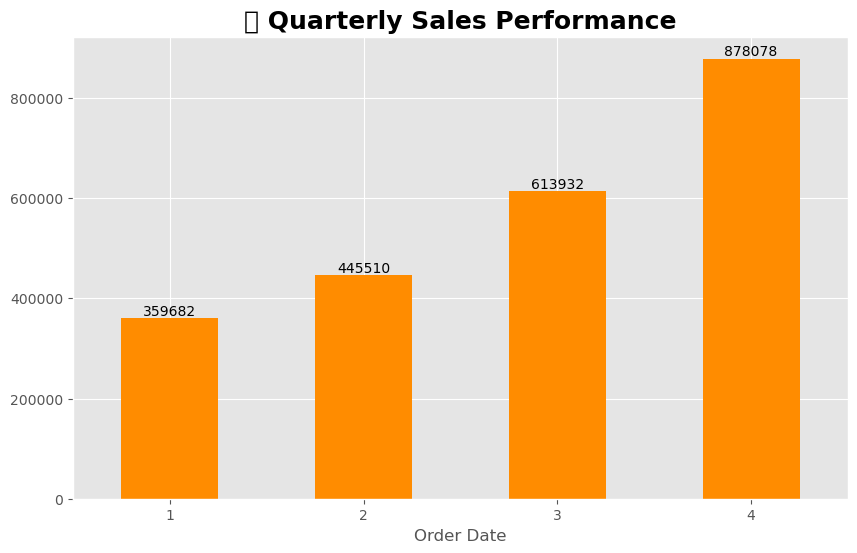

In [11]:
ax=(

quarter_summary

["Sales"]

.plot(

kind="bar",

figsize=(10,6),

color="darkorange"

)

)

plt.title(

"📊 Quarterly Sales Performance",

fontsize=18,

fontweight="bold"

)

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f")

plt.show()

## 🧠 Business Insight

Quarterly analysis simplifies long-term sales trends.

Questions to investigate:

- Which quarter contributes the highest revenue?
- Does the final quarter consistently outperform the others?
- Is there evidence of seasonal buying behaviour?

In [12]:
quarter_summary.sort_values("Sales")

,Sales,Profit
Order Date,,
1,359681.5758,48023.7440
2,445509.6196,55284.5395
3,613932.1057,72467.0785
4,878077.5592,110621.6597


## 💡 Business Recommendation

If one quarter consistently underperforms, management should investigate:

- Marketing effectiveness
- Seasonal demand
- Product availability
- Pricing strategies

Targeted campaigns during weaker quarters can improve annual revenue consistency.

C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128185 (\N{CHART WITH UPWARDS TREND AND YEN SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


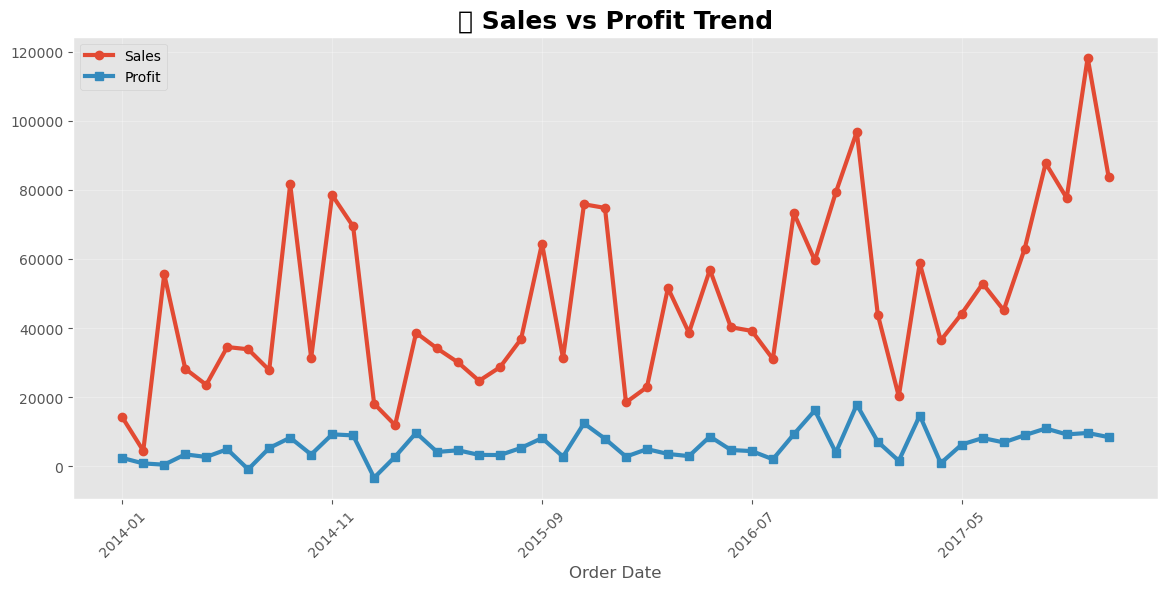

In [14]:
fig,ax=plt.subplots(figsize=(14,6))

monthly_summary["Total_Sales"].plot(

ax=ax,

label="Sales",

linewidth=3,

marker="o"

)

monthly_summary["Total_Profit"].plot(

ax=ax,

label="Profit",

linewidth=3,

marker="s"

)

plt.title(

"💹 Sales vs Profit Trend",

fontsize=18,

fontweight="bold"

)

plt.xticks(rotation=45)

plt.legend()

plt.grid(alpha=.3)

plt.show()

## 🧠 Business Insight

Comparing revenue and profit trends provides a more complete view of business health.

Possible observations:

- If sales increase while profit declines, discounts or operational costs may be affecting margins.
- If both sales and profit grow together, the business is achieving sustainable growth.
- Significant divergence between the two metrics warrants further investigation.

# ✅ Time Series Analysis Conclusion

### Key Findings

- Monthly sales trends reveal periods of strong and weak business performance.
- Seasonal patterns help optimize inventory and marketing strategies.
- Quarterly analysis provides a high-level view of business consistency.
- Comparing sales and profit trends highlights whether revenue growth is translating into financial success.

### Business Recommendation

- Increase inventory before historically strong months.
- Plan promotional campaigns during weaker periods.
- Monitor profit margins alongside sales to ensure sustainable business growth.